**# Machine Learning y Deep Learning**

Unidad 2

Practica 1: **Regresion Lineal Simple**

Facilitador: Dr. Jose Gabriel Rodriguez Rivas

Alumno: Ivan Moreno Galindo

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')

# https://drive.google.com/file/d/14LEG8lm0TbcrmEYeG-RgRvovDuPngmm4/view?usp=sharing
flie_id = "14LEG8lm0TbcrmEYeG-RgRvovDuPngmm4"

url = f"https://drive.google.com/uc?id={flie_id}"
df = pd.read_csv(url)

autos2 = pd.read_csv(url)

df.head()

Mounted at /content/drive


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,fuel-type_code,diesel,gas,fuel-type-map,horsepower-binned
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,13495.0,11.190476,1,False,True,1,Low
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,16500.0,11.190476,1,False,True,1,Low
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,5000.0,19,9.038462,16500.0,12.368421,1,False,True,1,Medium
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,5500.0,24,7.833333,13950.0,9.791667,1,False,True,1,Low
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,5500.0,18,10.681818,17450.0,13.055556,1,False,True,1,Low


In [2]:
X = df[['city-mpg' ]]
y = df['price']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [6]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error cuadratico medio (MSE): {mse}")
print(f"Coeficiente de determinacion (R^2): {r2:.2f}")

Error cuadratico medio (MSE): 74223480.07036026
Coeficiente de determinacion (R^2): 0.39


In [7]:
rmse = np.sqrt(mse)
print(f"Raiz del error cuadratico medio (RMSE): {rmse:.2f}")

Raiz del error cuadratico medio (RMSE): 8615.30


In [8]:
coef_df = pd.DataFrame({'Variable': X.columns, 'Coeficiente': model.coef_})
print(coef_df)
print(f"Inserseccion (bias): {model.intercept_:.2f}")

   Variable  Coeficiente
0  city-mpg  -742.942492
Inserseccion (bias): 31365.48


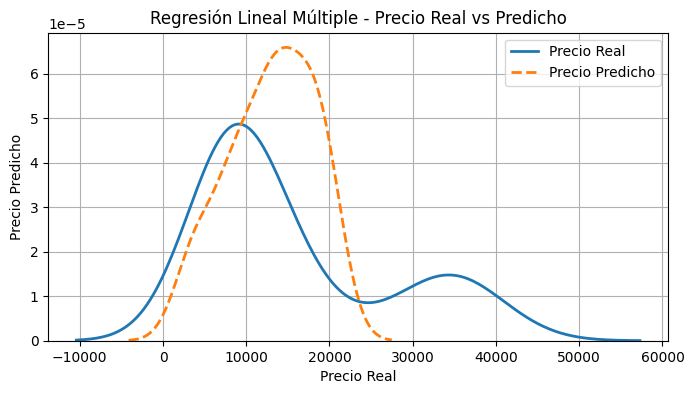

In [9]:
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Regresión Lineal Múltiple - Precio Real vs Predicho")
plt.grid(True)
plt.legend()
plt.show()

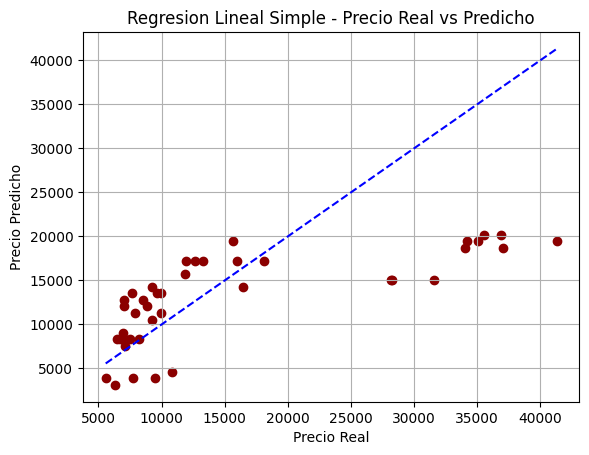

In [10]:
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Regresion Lineal Simple - Precio Real vs Predicho")
plt.grid(True)
plt.show()